In [7]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

POLICY_DATE = pd.Timestamp("2025-01-05")
FAKE_DATE   = pd.Timestamp("2024-01-05")
VAL_DAYS    = 90
GROUPS      = ["treated", "buffer", "control"]
SPEED, VOL  = "speed_median_mph", "n_trips"

def resolve_data_dir():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        return "/content/drive/MyDrive/nyc-crz-counterfactual"
    except Exception:
        return "./nyc-crz-counterfactual"

DATA_DIR  = resolve_data_dir()
FEAT_PATH = os.path.join(DATA_DIR, "crz_features_3grp.parquet")
BASE_PATH = os.path.join(DATA_DIR, "baseline_val_metrics.csv")
PROJ_OUT  = os.path.join(DATA_DIR, "crz_counterfactual_lgbm.parquet")
EFF_OUT   = os.path.join(DATA_DIR, "crz_effects.csv")

feat = pd.read_parquet(FEAT_PATH); feat["datetime"] = pd.to_datetime(feat["datetime"])
baseline = pd.read_csv(BASE_PATH) if os.path.exists(BASE_PATH) else None
VAL_START = POLICY_DATE - pd.Timedelta(days=VAL_DAYS)
print("Loaded", feat.shape, "| policy", POLICY_DATE.date(), "| fake-policy", FAKE_DATE.date())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded (78901, 29) | policy 2025-01-05 | fake-policy 2024-01-05


In [8]:
GBM_FEATURES = ["hour","dow","month","doy","is_weekend","is_holiday",
                "temperature_2m","precipitation","rain","snowfall",
                "wind_speed_10m","cloud_cover","precip_roll3"]
LGB_PARAMS = dict(objective="regression", n_estimators=500, learning_rate=0.05,
                  num_leaves=31, min_child_samples=50, subsample=0.8, subsample_freq=1,
                  colsample_bytree=0.8, verbosity=-1)

def mae(y,p):  return float(np.mean(np.abs(y-p)))
def rmse(y,p): return float(np.sqrt(np.mean((y-p)**2)))
def mape(y,p):
    m=y!=0; return float(np.mean(np.abs((y[m]-p[m])/y[m]))*100)

def fit_counterfactual(train, target, with_bands=False):
    b, a = np.polyfit(train["t_days"].to_numpy(), train[target].to_numpy(), 1)
    resid = train[target].to_numpy() - (a + b*train["t_days"].to_numpy())
    X = train[GBM_FEATURES]
    model = {"a": a, "b": b, "point": lgb.LGBMRegressor(**LGB_PARAMS).fit(X, resid)}
    if with_bands:
        qp = {**LGB_PARAMS, "objective": "quantile"}
        model["lo"] = lgb.LGBMRegressor(**{**qp,"alpha":0.05}).fit(X, resid)
        model["hi"] = lgb.LGBMRegressor(**{**qp,"alpha":0.95}).fit(X, resid)
    return model

def predict_counterfactual(model, df):
    trend = model["a"] + model["b"]*df["t_days"].to_numpy()
    X = df[GBM_FEATURES]
    out = {"cf": trend + model["point"].predict(X)}
    if "lo" in model:
        lo = trend + model["lo"].predict(X); hi = trend + model["hi"].predict(X)
        out["cf_lo"], out["cf_hi"] = np.minimum(lo,hi), np.maximum(lo,hi)
    return out

def gap_stats(df, target, cf="cf"):
    g = df[target].to_numpy() - df[cf].to_numpy()
    return float(np.mean(g)), float(np.mean(g)/np.mean(df[cf].to_numpy())*100)

def real_and_placebo(frame, target, bands=False):
    pre, post = frame[frame.is_pre], frame[~frame.is_pre]
    rpost = post.assign(**predict_counterfactual(fit_counterfactual(pre, target, bands), post))
    rg, rp = gap_stats(rpost, target)
    ptr   = frame[frame.datetime <  FAKE_DATE]
    ppost = frame[(frame.datetime >= FAKE_DATE) & (frame.datetime < POLICY_DATE)]
    plpost = ppost.assign(**predict_counterfactual(fit_counterfactual(ptr, target), ppost))
    pg, pp = gap_stats(plpost, target)
    return dict(real_gap=rg, real_pct=rp, plac_gap=pg, plac_pct=pp, real_post=rpost)

In [9]:
val_rows=[]
for grp in GROUPS:
    g = feat[(feat.group==grp) & feat.is_pre].sort_values("datetime")
    tr, va = g[g.datetime<VAL_START], g[g.datetime>=VAL_START]
    for tgt in (VOL, SPEED):
        yhat = predict_counterfactual(fit_counterfactual(tr, tgt), va)["cf"]; y=va[tgt].to_numpy()
        val_rows.append({"group":grp,"target":tgt,"RMSE":rmse(y,yhat),"MAE":mae(y,yhat),"MAPE%":mape(y,yhat)})
val = pd.DataFrame(val_rows)
if baseline is not None:
    bb = (baseline.sort_values("RMSE").groupby(["group","target"]).first().reset_index()
                  [["group","target","baseline","RMSE"]].rename(columns={"baseline":"best_baseline","RMSE":"base_RMSE"}))
    comp = val.merge(bb,on=["group","target"]); comp["RMSE_impr_%"]=(1-comp.RMSE/comp.base_RMSE)*100
    print(comp.round(3).to_string(index=False))
else:
    print(val.round(3).to_string(index=False))

  group           target    RMSE     MAE  MAPE%  best_baseline  base_RMSE  RMSE_impr_%
treated          n_trips 729.284 506.105 28.103 seasonal_trend    885.942       17.683
treated speed_median_mph   0.838   0.603  6.131  seasonal_mean      1.032       18.763
 buffer          n_trips 154.002 107.660 37.727  seasonal_mean    189.005       18.520
 buffer speed_median_mph   1.282   0.817  6.816 seasonal_trend      1.476       13.147
control          n_trips 131.406  94.149 22.773 seasonal_trend    149.949       12.366
control speed_median_mph   2.521   1.709 10.864 seasonal_trend      2.876       12.330


In [10]:
def build_diff(feat, a, b, target):
    cols = ["datetime","t_days","is_pre"] + GBM_FEATURES
    fa = feat[feat.group==a][cols+[target]].rename(columns={target:"_a"})
    fb = feat[feat.group==b][["datetime",target]].rename(columns={target:"_b"})
    d  = fa.merge(fb, on="datetime", how="inner")
    d["spd_diff"] = d["_a"] - d["_b"]
    return d

PAIRS = [("treated","control","primary"),
         ("treated","buffer","robustness"),
         ("buffer","control","cross-group placebo")]
spd_rows=[]; diff_proj={}
for a,b,role in PAIRS:
    d = build_diff(feat, a, b, SPEED)
    r = real_and_placebo(d, "spd_diff", bands=(role=="primary"))
    spd_rows.append({"pair":f"{a}-{b}","role":role,
                     "real2025_effect":r["real_gap"], "intime_placebo2024":r["plac_gap"]})
    diff_proj[(a,b)] = r["real_post"]
spd_eff = pd.DataFrame(spd_rows)
print("SPEED effect (mph), differenced counterfactual:")
print(spd_eff.round(3).to_string(index=False))
print("\nRead: treated-control (primary) clearly positive and clearing its placebo;")
print("buffer-control (cross-group placebo) near zero.")

SPEED effect (mph), differenced counterfactual:
           pair                role  real2025_effect  intime_placebo2024
treated-control             primary            1.087               1.440
 treated-buffer          robustness            0.425               0.325
 buffer-control cross-group placebo            0.660               1.120

Read: treated-control (primary) clearly positive and clearing its placebo;
buffer-control (cross-group placebo) near zero.


In [11]:
tc = diff_proj[("treated","control")].copy()
tc["month"] = tc["datetime"].dt.to_period("M").astype(str)
mon = tc.groupby("month").apply(
    lambda x: pd.Series({"effect_mph": (x["spd_diff"]-x["cf"]).mean()}), include_groups=False)
print("Monthly treated-control speed effect (mph):")
print(mon.round(3).to_string())
print(f"\nMonths positive: {(mon.effect_mph>0).sum()}/{len(mon)} | mean {mon.effect_mph.mean():+.3f} mph")

Monthly treated-control speed effect (mph):
         effect_mph
month              
2025-01       0.704
2025-02       1.144
2025-03       1.336
2025-04       1.033
2025-05       0.726
2025-06       1.325
2025-07       1.936
2025-08       1.748
2025-09       0.924
2025-10       0.609
2025-11       0.631
2025-12       0.872

Months positive: 12/12 | mean +1.082 mph


In [12]:
vol_rows=[]; absspd_rows=[]; vol_proj={}
for grp in GROUPS:
    g = feat[feat.group==grp]
    rv = real_and_placebo(g, VOL, bands=(grp=="treated"))
    vol_rows.append({"group":grp,"real2025_gap":rv["real_gap"],"real2025_%":rv["real_pct"],
                     "placebo2024_%":rv["plac_pct"]})
    vol_proj[grp]=rv["real_post"]
    rs = real_and_placebo(g, SPEED)
    absspd_rows.append({"group":grp,"real2025_gap":rs["real_gap"],"placebo2024_gap":rs["plac_gap"]})
vol_eff = pd.DataFrame(vol_rows); abs_spd = pd.DataFrame(absspd_rows)
print("VOLUME effect, per-series (descriptive — magnitude not causal for control):")
print(vol_eff.round(3).to_string(index=False))
print("\nPer-series ABSOLUTE speed (trend-biased; real~=placebo -> not usable):")
print(abs_spd.round(3).to_string(index=False))

VOLUME effect, per-series (descriptive — magnitude not causal for control):
  group  real2025_gap  real2025_%  placebo2024_%
treated       247.726       6.921          8.083
 buffer        14.188       2.271          9.671
control       182.359      27.270         15.873

Per-series ABSOLUTE speed (trend-biased; real~=placebo -> not usable):
  group  real2025_gap  placebo2024_gap
treated         0.857            0.822
 buffer         0.425            0.501
control        -0.236           -0.626


In [13]:
tc = diff_proj[("treated","control")][["datetime","spd_diff","cf","cf_lo","cf_hi"]].copy()
tc.insert(1,"series","speed_treated_minus_control"); tc=tc.rename(columns={"spd_diff":"actual"})
tv = vol_proj["treated"][["datetime",VOL,"cf","cf_lo","cf_hi"]].copy()
tv.insert(1,"series","volume_treated"); tv=tv.rename(columns={VOL:"actual"})
pd.concat([tc,tv],ignore_index=True).to_parquet(PROJ_OUT,index=False)
spd_eff.assign(kind="speed_diff").to_csv(EFF_OUT, index=False)
print("Saved projections ->", PROJ_OUT, "and effects ->", EFF_OUT)

Saved projections -> /content/drive/MyDrive/nyc-crz-counterfactual/crz_counterfactual_lgbm.parquet and effects -> /content/drive/MyDrive/nyc-crz-counterfactual/crz_effects.csv


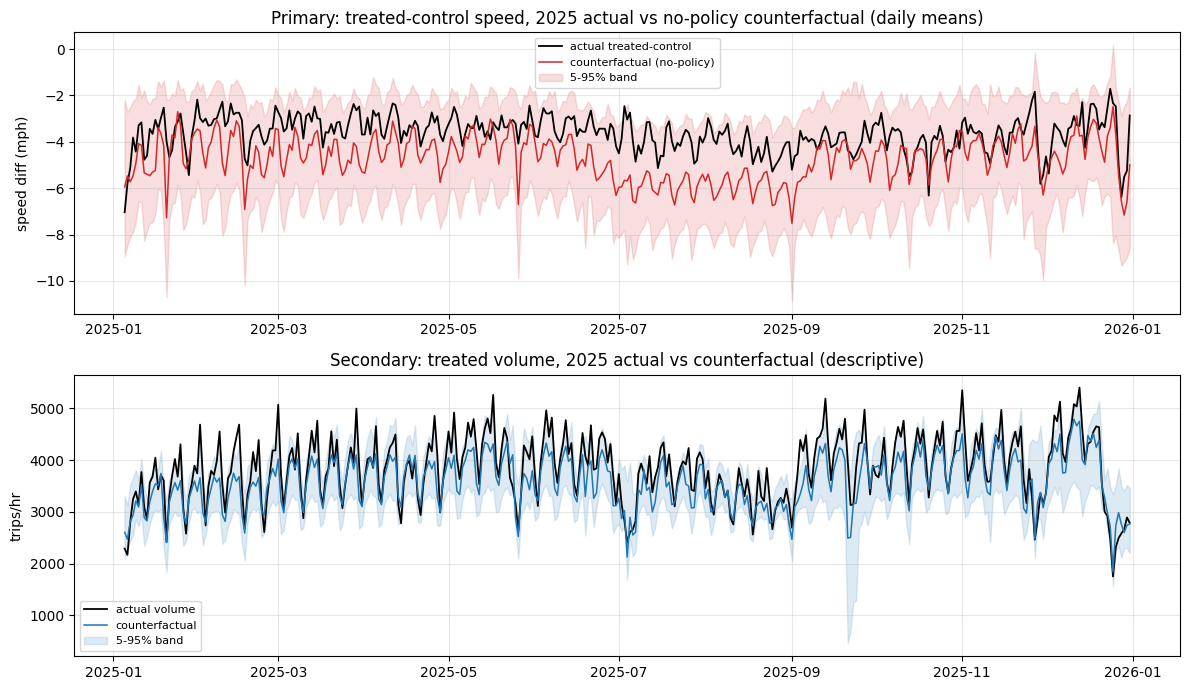

In [14]:
fig, axes = plt.subplots(2,1,figsize=(12,7))
d = diff_proj[("treated","control")].copy(); d["date"]=d["datetime"].dt.date
dd = d.groupby("date").agg(actual=("spd_diff","mean"),cf=("cf","mean"),lo=("cf_lo","mean"),hi=("cf_hi","mean"))
axes[0].plot(dd.index, dd.actual, "k", lw=1.3, label="actual treated-control")
axes[0].plot(dd.index, dd.cf, "tab:red", lw=1.1, label="counterfactual (no-policy)")
axes[0].fill_between(dd.index, dd.lo, dd.hi, color="tab:red", alpha=.15, label="5-95% band")
axes[0].set_ylabel("speed diff (mph)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)
axes[0].set_title("Primary: treated-control speed, 2025 actual vs no-policy counterfactual (daily means)")
v = vol_proj["treated"].copy(); v["date"]=v["datetime"].dt.date
vv = v.groupby("date").agg(actual=(VOL,"mean"),cf=("cf","mean"),lo=("cf_lo","mean"),hi=("cf_hi","mean"))
axes[1].plot(vv.index, vv.actual, "k", lw=1.3, label="actual volume")
axes[1].plot(vv.index, vv.cf, "tab:blue", lw=1.1, label="counterfactual")
axes[1].fill_between(vv.index, vv.lo, vv.hi, color="tab:blue", alpha=.15, label="5-95% band")
axes[1].set_ylabel("trips/hr"); axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)
axes[1].set_title("Secondary: treated volume, 2025 actual vs counterfactual (descriptive)")
fig.tight_layout(); plt.show()